# Netflix Movies & TV Shows — Exploratory Data Analysis

**Author:** Shaik Baji Shaida
**Goal:** Explore Netflix's public content catalog to uncover trends in genre popularity, content additions over time, and country-wise distribution of titles.

**Dataset:** Netflix Movies and TV Shows (originally sourced from Kaggle / Flixable, distributed via the TidyTuesday project)
**Tools:** Python, Pandas, Matplotlib, Seaborn


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)


## 2. Load the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## 3. Initial Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


In [4]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09
title,0,0.00
show_id,0,0.00
type,0,0.00
release_year,0,0.00
duration,0,0.00


## 4. Data Cleaning

Key cleaning steps:
- Fill missing `country`, `director`, and `cast` with `"Unknown"` (dropping them would lose too much data — these fields have high missing rates but the rest of the row is still valuable for other analyses).
- Drop the handful of rows missing `date_added` or `rating`, since those are needed for the time-based and rating-based analysis.
- Convert `date_added` to a proper datetime type and extract `year_added` and `month_added`.
- Split the multi-valued `listed_in` (genres) and `country` columns so each genre/country can be analyzed individually.


In [5]:
df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

df = df.dropna(subset=["date_added", "rating"]).copy()

df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="mixed")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

print("Shape after cleaning:", df.shape)
df.isnull().sum()


Shape after cleaning: (7770, 14)


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [6]:
# Explode multi-valued columns for genre and country level analysis
genre_df = df.assign(genre=df["listed_in"].str.split(", ")).explode("genre")
country_df = df.assign(country_single=df["country"].str.split(", ")).explode("country_single")
country_df = country_df[country_df["country_single"] != "Unknown"]

print("Genre rows:", genre_df.shape[0])
print("Country rows:", country_df.shape[0])


Genre rows: 17042
Country rows: 9048


## 5. Movies vs TV Shows

type
Movie      5372
TV Show    2398
Name: count, dtype: int64


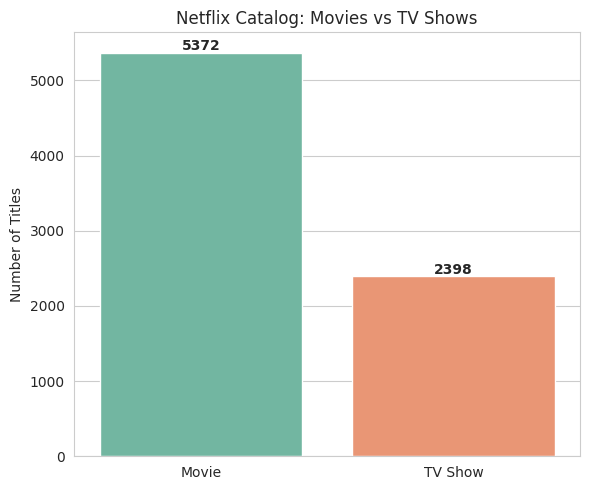

In [7]:
type_counts = df["type"].value_counts()
print(type_counts)

plt.figure(figsize=(6, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="Set2", legend=False)
plt.title("Netflix Catalog: Movies vs TV Shows")
plt.ylabel("Number of Titles")
plt.xlabel("")
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("charts/01_movies_vs_tvshows.png", dpi=150)
plt.show()


**Insight:** Movies dominate the Netflix catalog, making up roughly **70%** of all titles, while TV Shows account for the remaining **30%**.


## 6. Genre Popularity

genre
International Movies        2437
Dramas                      2105
Comedies                    1471
International TV Shows      1197
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


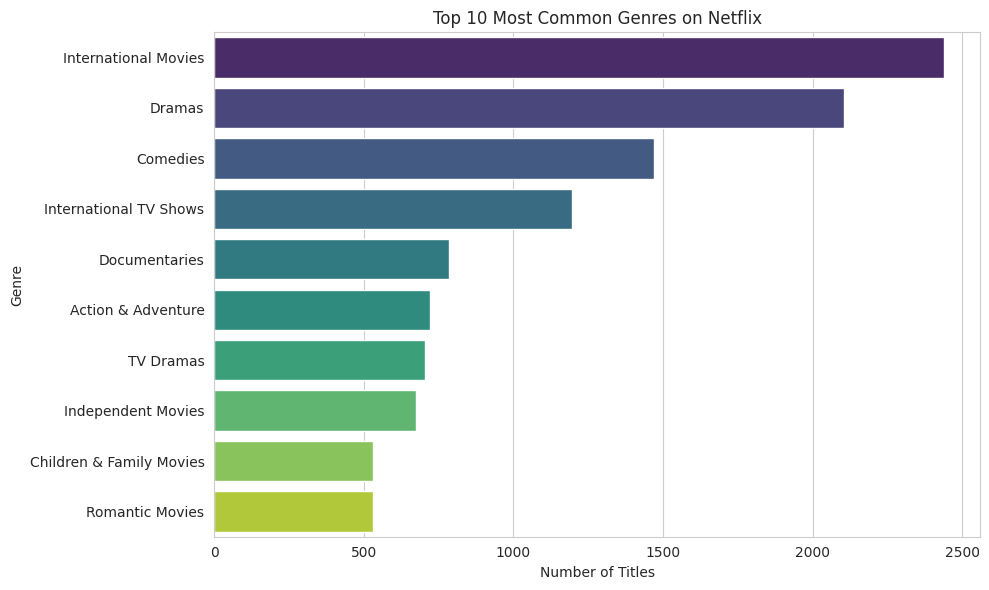

In [8]:
top_genres = genre_df["genre"].value_counts().head(10)
print(top_genres)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette="viridis", legend=False)
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("charts/02_top_genres.png", dpi=150)
plt.show()


**Insight:** International Movies, Dramas, and Comedies are the most frequently listed genres, reflecting Netflix's strong investment in localized and globally-appealing content.


## 7. Content Additions Over Time

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      25
2015      88
2016     440
2017    1222
2018    1684
2019    2153
2020    2009
2021     117
Name: count, dtype: int64


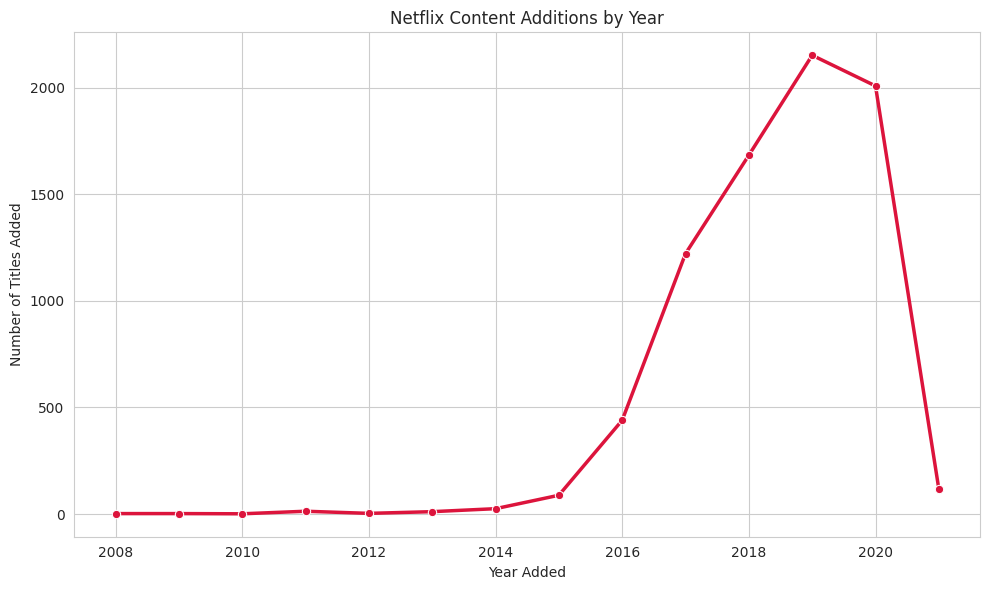

In [9]:
yearly_additions = df["year_added"].value_counts().sort_index()
print(yearly_additions)

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_additions.index, y=yearly_additions.values, marker="o", linewidth=2.5, color="crimson")
plt.title("Netflix Content Additions by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig("charts/03_content_by_year.png", dpi=150)
plt.show()


**Insight:** Content additions grew steadily year over year, peaking around **2019-2020**, coinciding with Netflix's aggressive global content expansion and the surge in streaming demand during the pandemic.


### 7.1 Seasonal Pattern — Which Months Get the Most New Content?

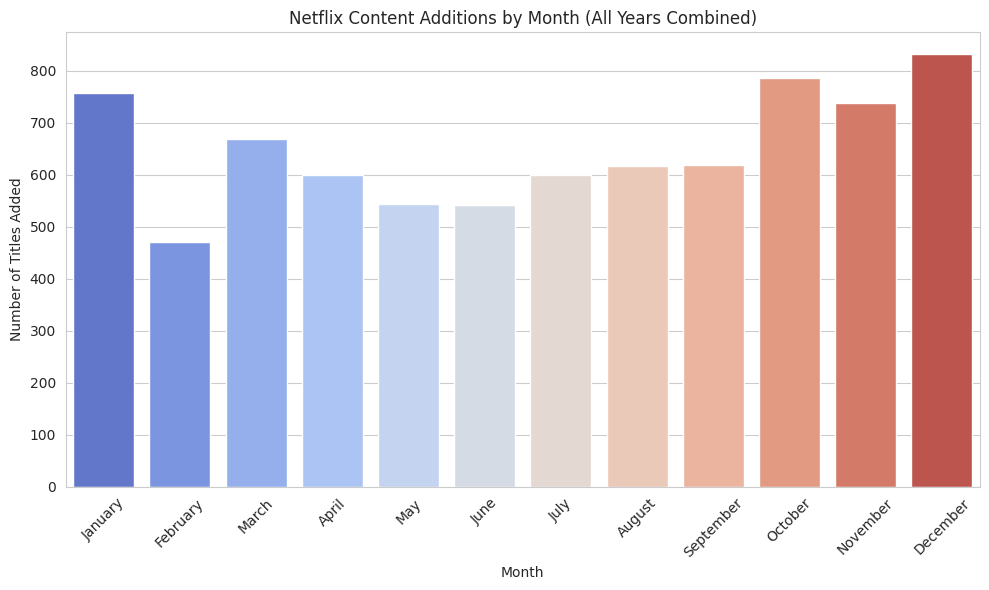

In [10]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly_additions = df["month_added"].value_counts().reindex(month_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_additions.index, y=monthly_additions.values, hue=monthly_additions.index,
            palette="coolwarm", legend=False)
plt.title("Netflix Content Additions by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/04_content_by_month.png", dpi=150)
plt.show()


## 8. Country-wise Distribution

country_single
United States     3287
India              990
United Kingdom     721
Canada             412
France             349
Japan              285
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64


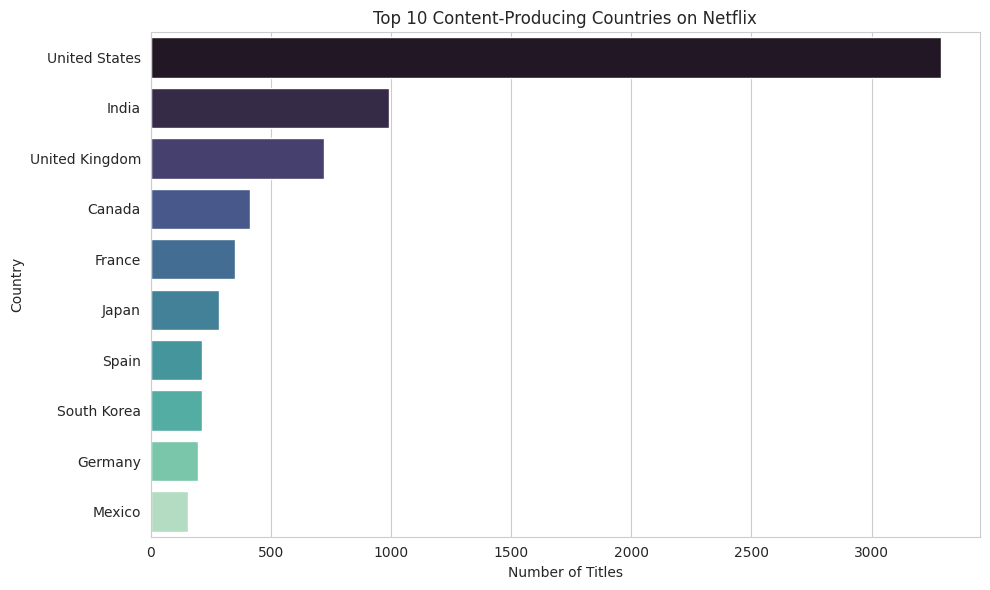

In [11]:
top_countries = country_df["country_single"].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="mako", legend=False)
plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("charts/05_top_countries.png", dpi=150)
plt.show()


**Insight:** The **United States** and **India** together account for a large share of Netflix's catalog, with the UK, Canada, and France rounding out the top content-producing countries — showing Netflix's strategy of pairing US originals with strong regional content hubs.


## 9. Content Ratings Distribution

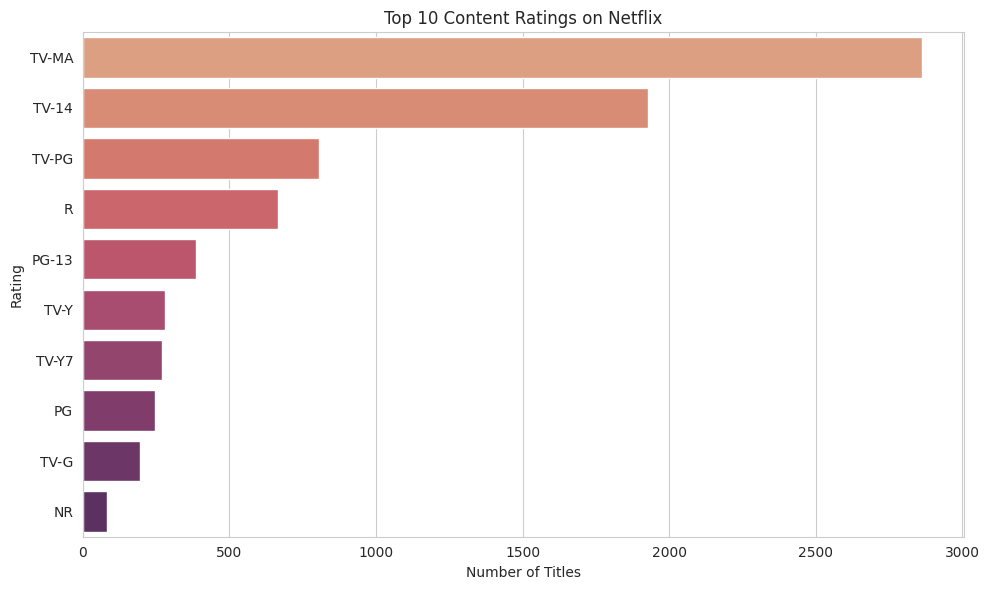

In [12]:
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.values, y=rating_counts.index, hue=rating_counts.index, palette="flare", legend=False)
plt.title("Top 10 Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("charts/06_ratings.png", dpi=150)
plt.show()


**Insight:** TV-MA (mature audience) and TV-14 are the most common ratings, indicating Netflix's catalog leans towards content for teens and adults rather than young children.


## 10. Movie Duration Analysis

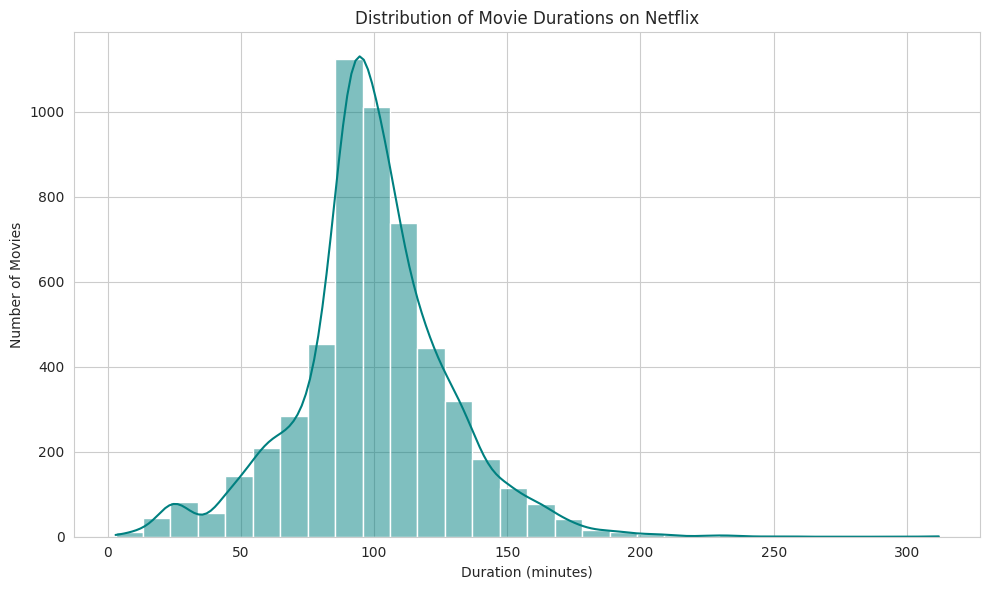

Average movie duration: 99.3 minutes
Median movie duration: 98.0 minutes


In [13]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = movies["duration"].str.replace(" min", "", regex=False).astype(float)

plt.figure(figsize=(10, 6))
sns.histplot(movies["duration_min"].dropna(), bins=30, kde=True, color="teal")
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("charts/07_movie_duration.png", dpi=150)
plt.show()

print("Average movie duration:", round(movies["duration_min"].mean(), 1), "minutes")
print("Median movie duration:", movies["duration_min"].median(), "minutes")


**Insight:** Most Netflix movies run between **80-120 minutes**, clustering around the mean of roughly **100 minutes**, consistent with standard feature-film length.


## 11. Key Takeaways

1. **Movies dominate the catalog** (~70%), but TV Shows have been a growing share of additions in recent years.
2. **International Movies, Dramas, and Comedies** are the most common genres — Netflix invests heavily in broad, globally-relatable content.
3. **Content additions peaked around 2019-2020**, reflecting Netflix's aggressive expansion phase before growth plateaued.
4. **The US and India lead content production**, with Netflix balancing US originals against strong regional hubs (India, UK, Canada, France).
5. **TV-MA and TV-14 are the most common ratings**, showing the catalog skews toward teen/adult audiences.
6. **Movies average ~100 minutes**, in line with standard theatrical runtimes.

## Next Steps
- Combine this analysis with a Power BI/Tableau dashboard for interactive exploration.
- Analyze director/cast frequency to identify Netflix's most-featured talent.
- Extend this into a genre-based recommendation system using content-based filtering.
